# 1. 데이터 로딩 

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# data loading
df = pd.read_csv("../data/Train_table_full.csv")
df = df.drop(columns=["scheduled_at"])

print(f"shape: {df.shape}")
df.head(3)

shape: (110521, 30)


,appt_id,patient_id,nhood_id,scheduled_time,appt_date,is_noshow,sms_received,lead_time_days,scheduled_date,gender,...,is_holiday,is_before_holiday,is_after_holiday,max_temp,min_temp,precip_mm,weather,temp_range,is_rainy,nhood_freq
0,5626772,9.598513e+13,58,08:36,2016-04-29,1,0,2,2016-04-27,F,...,0,0,0,23.4,20.8,11.9,61,2.6,1,835
1,5630279,7.336882e+14,26,15:05,2016-04-29,0,0,2,2016-04-27,F,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700
2,5630575,3.449833e+12,26,15:39,2016-04-29,0,0,2,2016-04-27,F,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   appt_id            110521 non-null  int64  
 1   patient_id         110521 non-null  float64
 2   nhood_id           110521 non-null  int64  
 3   scheduled_time     110521 non-null  object 
 4   appt_date          110521 non-null  object 
 5   is_noshow          110521 non-null  int64  
 6   sms_received       110521 non-null  int64  
 7   lead_time_days     110521 non-null  int64  
 8   scheduled_date     110521 non-null  object 
 9   gender             110521 non-null  object 
 10  age                110521 non-null  int64  
 11  has_hypertension   110521 non-null  int64  
 12  has_diabetes       110521 non-null  int64  
 13  has_alcoholism     110521 non-null  int64  
 14  has_handicap       110521 non-null  int64  
 15  scholarship        110521 non-null  int64  
 16  nh

In [151]:
df["y_noshow"] = 1 - df["is_noshow"].astype(int)
TARGET = "y_noshow"

print(df[TARGET].value_counts())
print(f"\n노쇼(=1) 비율: {df[TARGET].mean() * 100:.2f}%")

y_noshow
0    88202
1    22319
Name: count, dtype: int64

노쇼(=1) 비율: 20.19%


In [152]:
df["appt_date"] = pd.to_datetime(df["appt_date"])
df["scheduled_date"] = pd.to_datetime(df["scheduled_date"])
df["gender"] = (df["gender"] == "M").astype(int) # F=0, M=1
df["scheduled_time"] = pd.to_datetime(df["scheduled_time"], format="%H:%M").dt.hour

In [153]:
# 환자별 과거 노쇼 횟수 컬럼을 넣을 것인지

'''
데이터 누수 검사


df_check["appt_date"] = pd.to_datetime(df_check["appt_date"])
df_check["scheduled_at"] = pd.to_datetime(df_check["scheduled_at"])

print(f"전체 데이터: {len(df_check):,} 건")
print(f"환자 수: {df_check['patient_id'].nunique():,} 명")

# 환자별 예약 기록이 2개 이상인 경우만 분석
patient_counts = df_check['patient_id'].value_counts()
multi_visit_patients = patient_counts[patient_counts >= 2].index
multi_df = df_check[df_check['patient_id'].isin(multi_visit_patients)].copy()

print(f"\n복수 예약 환자: {len(multi_visit_patients):,} 명")
print(f"복수 예약 기록: {len(multi_df):,} 건 ({len(multi_df)/len(df_check)*100:.1f}%)")

# ============================================================
# 시간적 순서 역전 케이스 탐지
# ============================================================

def check_temporal_inconsistency(group):
    """환자별 예약에서 시간적 순서 역전 케이스 탐지"""
    if len(group) < 2:
        return None
    
    # 예약 시간순 정렬
    group_sched = group.sort_values('scheduled_at').reset_index(drop=True)
    # 실제 방문일순 정렬  
    group_appt = group.sort_values('appt_date').reset_index(drop=True)
    
    inconsistencies = []
    
    for i in range(len(group_sched)):
        for j in range(i+1, len(group_sched)):
            # i번째가 j번째보다 먼저 예약됨
            earlier_sched = group_sched.iloc[i]
            later_sched = group_sched.iloc[j]
            
            # 하지만 실제 방문일은 역전된 경우
            if earlier_sched['appt_date'] > later_sched['appt_date']:
                inconsistencies.append({
                    'patient_id': earlier_sched['patient_id'],
                    'case_type': 'scheduled_first_but_visit_later',
                    'first_appt_id': earlier_sched['appt_id'],
                    'first_scheduled_at': earlier_sched['scheduled_at'],
                    'first_appt_date': earlier_sched['appt_date'],
                    'first_noshow': earlier_sched['is_noshow'],
                    'second_appt_id': later_sched['appt_id'], 
                    'second_scheduled_at': later_sched['scheduled_at'],
                    'second_appt_date': later_sched['appt_date'],
                    'second_noshow': later_sched['is_noshow'],
                    'sched_gap_days': (later_sched['scheduled_at'] - earlier_sched['scheduled_at']).days,
                    'appt_gap_days': (earlier_sched['appt_date'] - later_sched['appt_date']).days,
                })
    
    return inconsistencies

# 전체 환자에 대해 검사
all_inconsistencies = []
problem_patients = []

for patient_id in multi_visit_patients[:1000]:  # 샘플링 (전체 하면 시간 오래 걸림)
    patient_data = multi_df[multi_df['patient_id'] == patient_id]
    inconsist = check_temporal_inconsistency(patient_data)
    if inconsist:
        all_inconsistencies.extend(inconsist)
        problem_patients.append(patient_id)

print(f"\n🔍 샘플 검사 결과 (1000명 중):")
print(f"시간적 순서 역전 케이스: {len(all_inconsistencies)} 건")
print(f"문제 있는 환자: {len(problem_patients)} 명")

if all_inconsistencies:
    inconsist_df = pd.DataFrame(all_inconsistencies)
    print(f"\n상위 5개 케이스:")
    print(inconsist_df[['patient_id', 'sched_gap_days', 'appt_gap_days', 
                       'first_scheduled_at', 'second_scheduled_at',
                       'first_appt_date', 'second_appt_date']].head().to_string())

'''

# 샘플 검사 결과 (1000명 중):
# 시간적 순서 역전 케이스: 4489 건
# 문제 있는 환자: 703 명
# 이전 예약이 나중에 방문한 케이스가 꽤 많음. 데이터 누수 위험이 존재하므로 과거 노쇼 횟수 계산을 넣지 않기로 결정.


'\n데이터 누수 검사\n\n\ndf_check["appt_date"] = pd.to_datetime(df_check["appt_date"])\ndf_check["scheduled_at"] = pd.to_datetime(df_check["scheduled_at"])\n\nprint(f"전체 데이터: {len(df_check):,} 건")\nprint(f"환자 수: {df_check[\'patient_id\'].nunique():,} 명")\n\n# 환자별 예약 기록이 2개 이상인 경우만 분석\npatient_counts = df_check[\'patient_id\'].value_counts()\nmulti_visit_patients = patient_counts[patient_counts >= 2].index\nmulti_df = df_check[df_check[\'patient_id\'].isin(multi_visit_patients)].copy()\n\nprint(f"\n복수 예약 환자: {len(multi_visit_patients):,} 명")\nprint(f"복수 예약 기록: {len(multi_df):,} 건 ({len(multi_df)/len(df_check)*100:.1f}%)")\n\n# ============================================================\n# 시간적 순서 역전 케이스 탐지\n# ============================================================\n\ndef check_temporal_inconsistency(group):\n    """환자별 예약에서 시간적 순서 역전 케이스 탐지"""\n    if len(group) < 2:\n        return None\n\n    # 예약 시간순 정렬\n    group_sched = group.sort_values(\'scheduled_at\').reset_index(drop=True)\n    

In [154]:
df.columns

Index(['appt_id', 'patient_id', 'nhood_id', 'scheduled_time', 'appt_date',
       'is_noshow', 'sms_received', 'lead_time_days', 'scheduled_date',
       'gender', 'age', 'has_hypertension', 'has_diabetes', 'has_alcoholism',
       'has_handicap', 'scholarship', 'nhood_name', 'dow', 'month',
       'is_weekend', 'is_holiday', 'is_before_holiday', 'is_after_holiday',
       'max_temp', 'min_temp', 'precip_mm', 'weather', 'temp_range',
       'is_rainy', 'nhood_freq', 'y_noshow'],
      dtype='object')

In [155]:
df.nhood_freq

0          835
1          700
2          700
3         2262
4          849
          ... 
110516    5805
110517    5805
110518    5805
110519    5805
110520    5805
Name: nhood_freq, Length: 110521, dtype: int64

In [156]:
# nhood_freq 데이터 누수 위험 검증
print("=== nhood_freq 데이터 누수 검증 ===")

# 1. nhood_freq 값 확인
print(f"nhood_freq 고유값 개수: {df['nhood_freq'].nunique()}")
print(f"nhood_freq 범위: [{df['nhood_freq'].min()}, {df['nhood_freq'].max()}]")

# 2. 동네별 실제 예약 건수와 비교
nhood_check = df.groupby('nhood_id').agg({
    'nhood_freq': 'first',
    'appt_id': 'count'
}).rename(columns={'nhood_freq': 'freq_value', 'appt_id': 'actual_count'})

print(f"\n동네별 비교 (상위 10개):")
print(nhood_check.head(10))

# 3. 일치 여부 확인
match_ratio = (nhood_check['freq_value'] == nhood_check['actual_count']).mean()
print(f"\nnhood_freq = 실제 건수인 동네 비율: {match_ratio*100:.1f}%")

# 4. 시간별 변화 확인 (누수 위험 테스트)
print(f"\n=== 시간 기반 누수 위험 검증 ===")

# 시간순 정렬
df_sorted = df.sort_values('appt_date').reset_index(drop=True)

# 초기 30% 데이터에서 동네별 건수
early_30 = int(len(df_sorted) * 0.3)
early_nhood_counts = df_sorted.iloc[:early_30].groupby('nhood_id').size()

# 전체 데이터에서 동네별 건수  
full_nhood_counts = df_sorted.groupby('nhood_id').size()

# 비교
comparison = pd.DataFrame({
    'early_30_percent': early_nhood_counts,
    'nhood_freq_value': df_sorted.groupby('nhood_id')['nhood_freq'].first(),
    'full_count': full_nhood_counts
}).fillna(0)

# nhood_freq가 전체 건수와 일치하는지 확인
full_match = (comparison['nhood_freq_value'] == comparison['full_count']).mean()
print(f"nhood_freq = 전체 건수 일치율: {full_match*100:.1f}%")

if full_match > 0.9:  # 90% 이상 일치하면
    print(f"🚨 데이터 누수 위험 HIGH!")
    print(f"   nhood_freq는 전체 데이터의 동네별 건수를 미리 계산한 값으로 보임")
    print(f"   → 학습 시 제외 권장")
else:
    print(f"✅ 데이터 누수 위험 LOW")
    print(f"   nhood_freq는 외부 정보 (인구통계 등) 일 가능성")

=== nhood_freq 데이터 누수 검증 ===
nhood_freq 고유값 개수: 78
nhood_freq 범위: [2, 7717]

동네별 비교 (상위 10개):
          freq_value  actual_count
nhood_id                          
1                  8             8
2               2262          2262
3                271           271
4                282           282
5                423           423
6               1907          1907
7                858           858
8                312           312
9               2773          2773
10              2565          2565

nhood_freq = 실제 건수인 동네 비율: 100.0%

=== 시간 기반 누수 위험 검증 ===
nhood_freq = 전체 건수 일치율: 100.0%
🚨 데이터 누수 위험 HIGH!
   nhood_freq는 전체 데이터의 동네별 건수를 미리 계산한 값으로 보임
   → 학습 시 제외 권장


# 2. 시간 기반 데이터 분할 (70:15:15)

In [157]:
DROP_COLS = [
    "appt_id", "patient_id", "nhood_id",
    "scheduled_date", "appt_date", "scheduled_time",
    "nhood_name", "nhood_freq", "is_noshow",
    TARGET
]

# 모델 학습 시 feature로 사용하지 않기 위해서 drop_cols 설정

FEATURES = [c for c in df.columns if c not in DROP_COLS]
print(f"사용할 피처 ({len(FEATURES)}개):\n{FEATURES}")


사용할 피처 (21개):
['sms_received', 'lead_time_days', 'gender', 'age', 'has_hypertension', 'has_diabetes', 'has_alcoholism', 'has_handicap', 'scholarship', 'dow', 'month', 'is_weekend', 'is_holiday', 'is_before_holiday', 'is_after_holiday', 'max_temp', 'min_temp', 'precip_mm', 'weather', 'temp_range', 'is_rainy']


In [158]:
# ══════════════════════════════════════════════════════════════
# 피처 엔지니어링 + 시간 기반 데이터 분할 (70:15:15)
# ══════════════════════════════════════════════════════════════

# ── 0. 같은 날 동일 환자 예약 건수 (라벨 미사용 → 분할 전 계산 가능) ──
df['same_day_appts'] = df.groupby(['patient_id', 'appt_date'])[TARGET].transform('count')

# ── 시간순 정렬 & 분할 ──
df = df.sort_values("appt_date").reset_index(drop=True)
n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df  = df.iloc[valid_end:].copy()

# ══════════════════════════════════════════════════════════════
# 1. nhood_noshow_rate (Train → Valid/Test 매핑)
# ══════════════════════════════════════════════════════════════
nhood_noshow_rate = train_df.groupby('nhood_id')[TARGET].mean()
global_noshow_rate = train_df[TARGET].mean()

train_df['nhood_noshow_rate'] = train_df['nhood_id'].map(nhood_noshow_rate)
valid_df['nhood_noshow_rate'] = valid_df['nhood_id'].map(nhood_noshow_rate).fillna(global_noshow_rate)
test_df['nhood_noshow_rate']  = test_df['nhood_id'].map(nhood_noshow_rate).fillna(global_noshow_rate)

# ══════════════════════════════════════════════════════════════
# 2. 환자 기반 피처 (split 후 기간별 집계 → 누수 완전 차단)
#
#   Train : 내부 시간순 누적 (shift로 현재 행 제외)
#   Valid : Train 전체의 환자별 집계 → 매핑 (시간 역전 無)
#   Test  : Train+Valid 전체의 환자별 집계 → 매핑 (시간 역전 無)
# ══════════════════════════════════════════════════════════════

def compute_patient_stats(history_df, target_col):
    """완료된 기간의 환자별 통계 집계"""
    stats = history_df.groupby('patient_id').agg(
        patient_appt_count=(target_col, 'count'),
        patient_noshow_count=(target_col, 'sum'),
    )
    stats['patient_noshow_rate'] = (
        stats['patient_noshow_count'] / stats['patient_appt_count']
    )
    return stats

def apply_patient_features(target_df, stats, global_rate):
    """환자 통계를 대상 DataFrame에 매핑 (미등장 환자 = 전체 평균)"""
    target_df['patient_appt_count']   = target_df['patient_id'].map(stats['patient_appt_count']).fillna(0).astype(int)
    target_df['patient_noshow_count'] = target_df['patient_id'].map(stats['patient_noshow_count']).fillna(0).astype(int)
    target_df['patient_noshow_rate']  = target_df['patient_id'].map(stats['patient_noshow_rate']).fillna(global_rate)
    target_df['is_first_visit']       = (target_df['patient_appt_count'] == 0).astype(int)
    return target_df

# ── Train: 내부 시간순 누적 (현재 행 제외) ──
train_df = train_df.sort_values('appt_date').reset_index(drop=True)
train_df['patient_noshow_count'] = (
    train_df.groupby('patient_id')[TARGET]
    .transform(lambda s: s.shift(1).expanding().sum())
    .fillna(0).astype(int)
)
train_df['patient_appt_count'] = train_df.groupby('patient_id').cumcount()
train_df['patient_noshow_rate'] = np.where(
    train_df['patient_appt_count'] > 0,
    train_df['patient_noshow_count'] / train_df['patient_appt_count'],
    global_noshow_rate                        # 신규 환자 → 전체 평균
)
train_df['is_first_visit'] = (train_df['patient_appt_count'] == 0).astype(int)

# ── Valid: Train 전체 집계 → 매핑 (완전히 깨끗, 역전 없음) ──
train_stats = compute_patient_stats(train_df, TARGET)
valid_df = apply_patient_features(valid_df, train_stats, global_noshow_rate)

# ── Test: Train+Valid 전체 집계 → 매핑 (완전히 깨끗, 역전 없음) ──
train_valid_stats = compute_patient_stats(
    pd.concat([train_df[['patient_id', TARGET]],
               valid_df[['patient_id', TARGET]]]),
    TARGET
)
test_df = apply_patient_features(test_df, train_valid_stats, global_noshow_rate)

# ══════════════════════════════════════════════════════════════
# FEATURES 확정
# ══════════════════════════════════════════════════════════════
POST_SPLIT_FEATURES = [
    'nhood_noshow_rate',
    'patient_appt_count', 'patient_noshow_count',
    'patient_noshow_rate', 'is_first_visit',
    'same_day_appts',
]
FEATURES_FINAL = FEATURES + POST_SPLIT_FEATURES

X_train, y_train = train_df[FEATURES_FINAL], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES_FINAL], valid_df[TARGET]
X_test,  y_test  = test_df[FEATURES_FINAL],  test_df[TARGET]

print(f"사용할 피처 ({len(FEATURES_FINAL)}개):")
for i, f in enumerate(FEATURES_FINAL, 1):
    print(f"  {i:2d}. {f}")

print(f"\n{'='*50}")
print(f"Train : {len(train_df):,} ({len(train_df)/n*100:.1f}%)  기간: {train_df['appt_date'].min().date()} ~ {train_df['appt_date'].max().date()}")
print(f"Valid : {len(valid_df):,} ({len(valid_df)/n*100:.1f}%)  기간: {valid_df['appt_date'].min().date()} ~ {valid_df['appt_date'].max().date()}")
print(f"Test  : {len(test_df):,}  ({len(test_df)/n*100:.1f}%)  기간: {test_df['appt_date'].min().date()} ~ {test_df['appt_date'].max().date()}")
print(f"\n각 세트 노쇼 비율:")
print(f"  Train: {y_train.mean()*100:.2f}%  |  Valid: {y_valid.mean()*100:.2f}%  |  Test: {y_test.mean()*100:.2f}%")

print(f"\n{'='*50}")
print(f"📋 환자 피처 누수 방지 요약:")
print(f"  Train 내 신규 환자 비율: {train_df['is_first_visit'].mean()*100:.1f}%")
print(f"  Valid 내 신규 환자 비율: {valid_df['is_first_visit'].mean()*100:.1f}%")
print(f"  Test  내 신규 환자 비율: {test_df['is_first_visit'].mean()*100:.1f}%")
print(f"  Valid 환자 피처 출처: Train 전체 집계 (역전 無)")
print(f"  Test  환자 피처 출처: Train+Valid 전체 집계 (역전 無)")

사용할 피처 (27개):
   1. sms_received
   2. lead_time_days
   3. gender
   4. age
   5. has_hypertension
   6. has_diabetes
   7. has_alcoholism
   8. has_handicap
   9. scholarship
  10. dow
  11. month
  12. is_weekend
  13. is_holiday
  14. is_before_holiday
  15. is_after_holiday
  16. max_temp
  17. min_temp
  18. precip_mm
  19. weather
  20. temp_range
  21. is_rainy
  22. nhood_noshow_rate
  23. patient_appt_count
  24. patient_noshow_count
  25. patient_noshow_rate
  26. is_first_visit
  27. same_day_appts

Train : 77,364 (70.0%)  기간: 2016-04-29 ~ 2016-05-30
Valid : 16,578 (15.0%)  기간: 2016-05-30 ~ 2016-06-03
Test  : 16,579  (15.0%)  기간: 2016-06-03 ~ 2016-06-08

각 세트 노쇼 비율:
  Train: 20.90%  |  Valid: 19.07%  |  Test: 18.05%

📋 환자 피처 누수 방지 요약:
  Train 내 신규 환자 비율: 63.0%
  Valid 내 신규 환자 비율: 46.6%
  Test  내 신규 환자 비율: 43.4%
  Valid 환자 피처 출처: Train 전체 집계 (역전 無)
  Test  환자 피처 출처: Train+Valid 전체 집계 (역전 無)


# 3. XGBoost 모델 학습

In [159]:
# scale_pos_weight

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}  (neg:{neg:,} / pos:{pos:,})")


scale_pos_weight = 3.79  (neg:61,198 / pos:16,166)


In [160]:
params = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    random_state=42,
    early_stopping_rounds=30,
    n_jobs=-1,
)

model = xgb.XGBClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50,
)

print(f"\n최적 반복 횟수: {model.best_iteration}")
print(f"최적 검증 logloss: {model.best_score:.4f}")

[0]	validation_0-logloss:0.68988	validation_1-logloss:0.69129
[50]	validation_0-logloss:0.57599	validation_1-logloss:0.60914
[100]	validation_0-logloss:0.56175	validation_1-logloss:0.59546
[150]	validation_0-logloss:0.55412	validation_1-logloss:0.59014
[200]	validation_0-logloss:0.54688	validation_1-logloss:0.58417
[250]	validation_0-logloss:0.54029	validation_1-logloss:0.58194
[300]	validation_0-logloss:0.53424	validation_1-logloss:0.57530
[350]	validation_0-logloss:0.52871	validation_1-logloss:0.57228
[400]	validation_0-logloss:0.52274	validation_1-logloss:0.56983
[450]	validation_0-logloss:0.51770	validation_1-logloss:0.56713
[482]	validation_0-logloss:0.51441	validation_1-logloss:0.56716

최적 반복 횟수: 452
최적 검증 logloss: 0.5670


# 4. 모델 평가 및 결과 분석

In [161]:
def evaluate(model, X, y, label=""):
    """분류 모델 평가 함수"""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec  = recall_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    auc  = roc_auc_score(y, y_prob)
    
    print(f"\n{'='*50}")
    print(f"📊 {label} 성능")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['방문(0)', '노쇼(1)'])}")
    
    return {"label": label, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc, "y_pred": y_pred}

train_result = evaluate(model, X_train, y_train, "Train")
valid_result = evaluate(model, X_valid, y_valid, "Validation")
test_result  = evaluate(model, X_test,  y_test,  "Test")


📊 Train 성능
  Accuracy  : 0.6871
  Precision : 0.3872
  Recall    : 0.8542
  F1-Score  : 0.5329
  ROC-AUC   : 0.8317

              precision    recall  f1-score   support

       방문(0)       0.94      0.64      0.76     61198
       노쇼(1)       0.39      0.85      0.53     16166

    accuracy                           0.69     77364
   macro avg       0.67      0.75      0.65     77364
weighted avg       0.83      0.69      0.72     77364


📊 Validation 성능
  Accuracy  : 0.6405
  Precision : 0.3055
  Recall    : 0.6953
  F1-Score  : 0.4245
  ROC-AUC   : 0.7250

              precision    recall  f1-score   support

       방문(0)       0.90      0.63      0.74     13417
       노쇼(1)       0.31      0.70      0.42      3161

    accuracy                           0.64     16578
   macro avg       0.60      0.66      0.58     16578
weighted avg       0.78      0.64      0.68     16578


📊 Test 성능
  Accuracy  : 0.6480
  Precision : 0.2928
  Recall    : 0.6715
  F1-Score  : 0.4078
  ROC-AUC 

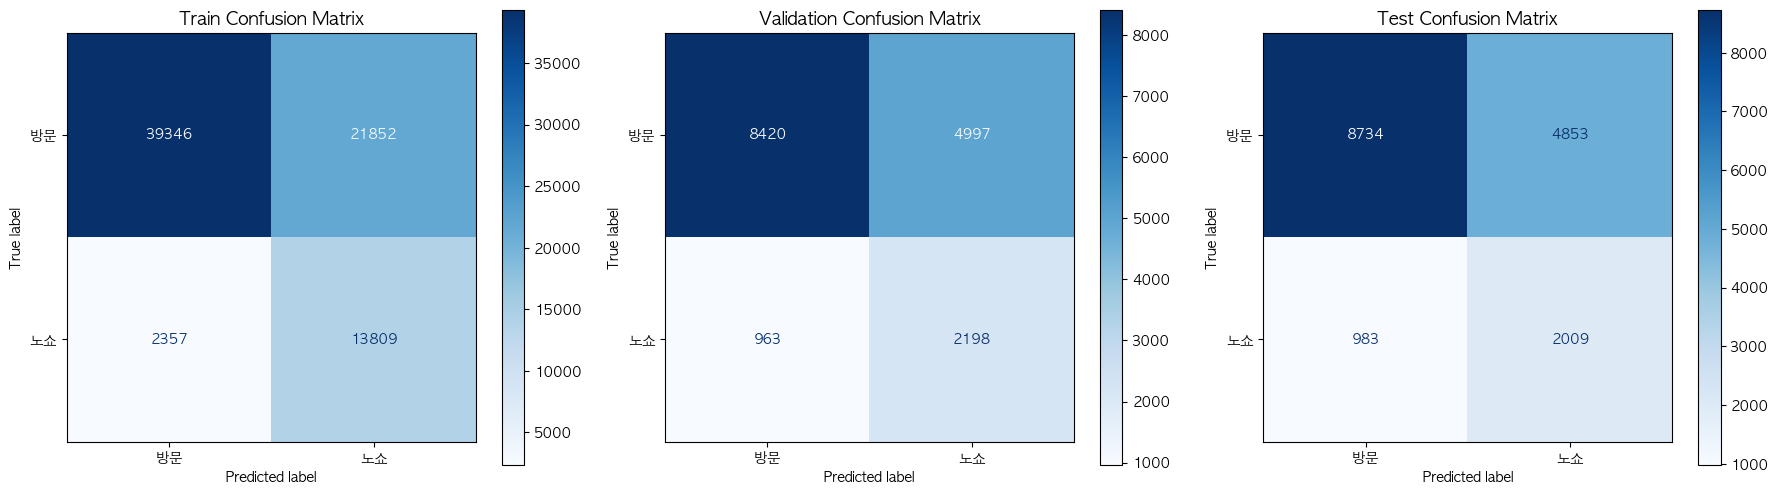

In [162]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (X_set, y_set, title) in zip(axes, [
    (X_train, y_train, "Train"),
    (X_valid, y_valid, "Validation"),
    (X_test,  y_test,  "Test"),
]):
    y_pred = model.predict(X_set)
    ConfusionMatrixDisplay.from_predictions(
        y_set, y_pred, display_labels=["방문", "노쇼"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"{title} Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# 5. Threshold 튜닝 (Validation 기반)

🎯 최적 Threshold = 0.48
   → F1        = 0.4229
   → Precision = 0.2941
   → Recall    = 0.7520

참고: 기본 Threshold(0.50) 대비
   F1 변화: 0.4214 → 0.4229  (+0.0015)


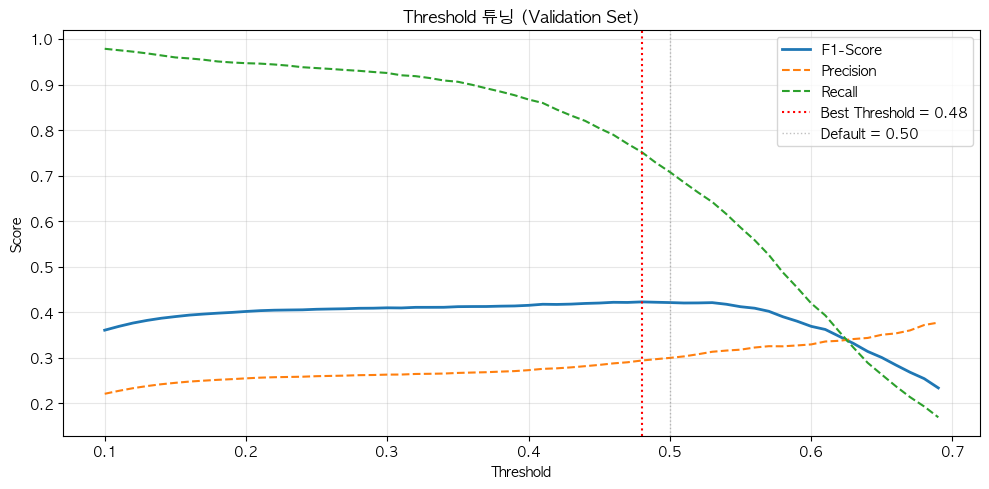

In [123]:
# ============================================================
# Validation 셋에서 F1을 최대화하는 최적 Threshold 탐색
# ============================================================
from sklearn.metrics import f1_score, precision_recall_curve

y_valid_prob = model.predict_proba(X_valid)[:, 1]

# 0.01 ~ 0.99 구간 탐색
thresholds = np.arange(0.10, 0.70, 0.01)
results = []

for th in thresholds:
    y_pred_th = (y_valid_prob >= th).astype(int)
    f1  = f1_score(y_valid, y_pred_th)
    pre = precision_score(y_valid, y_pred_th, zero_division=0)
    rec = recall_score(y_valid, y_pred_th)
    results.append({"threshold": th, "f1": f1, "precision": pre, "recall": rec})

res_df = pd.DataFrame(results)
best_row = res_df.loc[res_df["f1"].idxmax()]
best_th = best_row["threshold"]

print(f"{'='*50}")
print(f"🎯 최적 Threshold = {best_th:.2f}")
print(f"   → F1        = {best_row['f1']:.4f}")
print(f"   → Precision = {best_row['precision']:.4f}")
print(f"   → Recall    = {best_row['recall']:.4f}")
print(f"{'='*50}")
print(f"\n참고: 기본 Threshold(0.50) 대비")
row_50 = res_df.loc[(res_df["threshold"] - 0.50).abs().idxmin()]
print(f"   F1 변화: {row_50['f1']:.4f} → {best_row['f1']:.4f}  ({best_row['f1']-row_50['f1']:+.4f})")

# ── 시각화 ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_df["threshold"], res_df["f1"],       label="F1-Score", linewidth=2)
ax.plot(res_df["threshold"], res_df["precision"], label="Precision", linestyle="--")
ax.plot(res_df["threshold"], res_df["recall"],    label="Recall", linestyle="--")
ax.axvline(best_th, color="red", linestyle=":", linewidth=1.5, label=f"Best Threshold = {best_th:.2f}")
ax.axvline(0.50,    color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Default = 0.50")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold 튜닝 (Validation Set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

📊 Test 성능 비교: 기본(0.50) vs 최적(0.48)
지표             기본(0.50)         최적         변화
-------------------------------------------------------
Accuracy         0.6465     0.6267    -0.0198
Precision        0.2901     0.2853    -0.0047
Recall           0.6624     0.7102    +0.0478
F1-Score         0.4035     0.4071    +0.0037
ROC-AUC          0.7205     0.7205    (확률 기반)

              precision    recall  f1-score   support

       방문(0)       0.91      0.61      0.73     13587
       노쇼(1)       0.29      0.71      0.41      2992

    accuracy                           0.63     16579
   macro avg       0.60      0.66      0.57     16579
weighted avg       0.79      0.63      0.67     16579



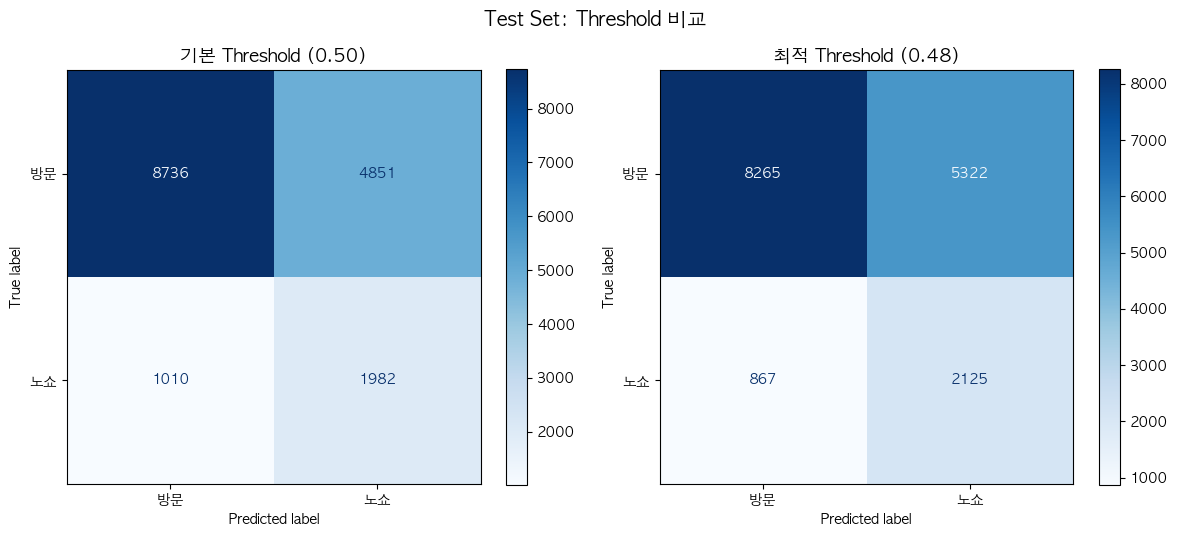

In [124]:
# ============================================================
# 최적 Threshold 적용 → Test 셋 최종 평가
# ============================================================
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_opt  = (y_test_prob >= best_th).astype(int)
y_test_def  = model.predict(X_test)  # 기본 0.5

print(f"{'='*55}")
print(f"📊 Test 성능 비교: 기본(0.50) vs 최적({best_th:.2f})")
print(f"{'='*55}")
print(f"{'지표':<12} {'기본(0.50)':>10} {'최적':>10} {'변화':>10}")
print(f"{'-'*55}")

for name, func in [("Accuracy", accuracy_score), ("Precision", precision_score),
                    ("Recall", recall_score), ("F1-Score", f1_score)]:
    v_def = func(y_test, y_test_def)
    v_opt = func(y_test, y_test_opt)
    diff = v_opt - v_def
    print(f"{name:<12} {v_def:>10.4f} {v_opt:>10.4f} {diff:>+10.4f}")

auc_val = roc_auc_score(y_test, y_test_prob)
print(f"{'ROC-AUC':<12} {auc_val:>10.4f} {auc_val:>10.4f} {'(확률 기반)':>10}")

print(f"\n{classification_report(y_test, y_test_opt, target_names=['방문(0)', '노쇼(1)'])}")

# ── Confusion Matrix 비교 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y_p, title) in zip(axes, [
    (y_test_def, f"기본 Threshold (0.50)"),
    (y_test_opt, f"최적 Threshold ({best_th:.2f})"),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p, display_labels=["방문", "노쇼"],
        cmap="Blues", ax=ax
    )
    ax.set_title(title, fontsize=13)
plt.suptitle("Test Set: Threshold 비교", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 6. 피처 엔지니어링

In [129]:
# 신규 환자 vs 재방문 환자의 실제 노쇼율 차이 확인
print("재방문 환자 노쇼율:", train_df[train_df['is_first_visit']==0][TARGET].mean())
print("신규 환자 노쇼율:",   train_df[train_df['is_first_visit']==1][TARGET].mean())

재방문 환자 노쇼율: 0.2265220433869839
신규 환자 노쇼율: 0.19994260413250245
